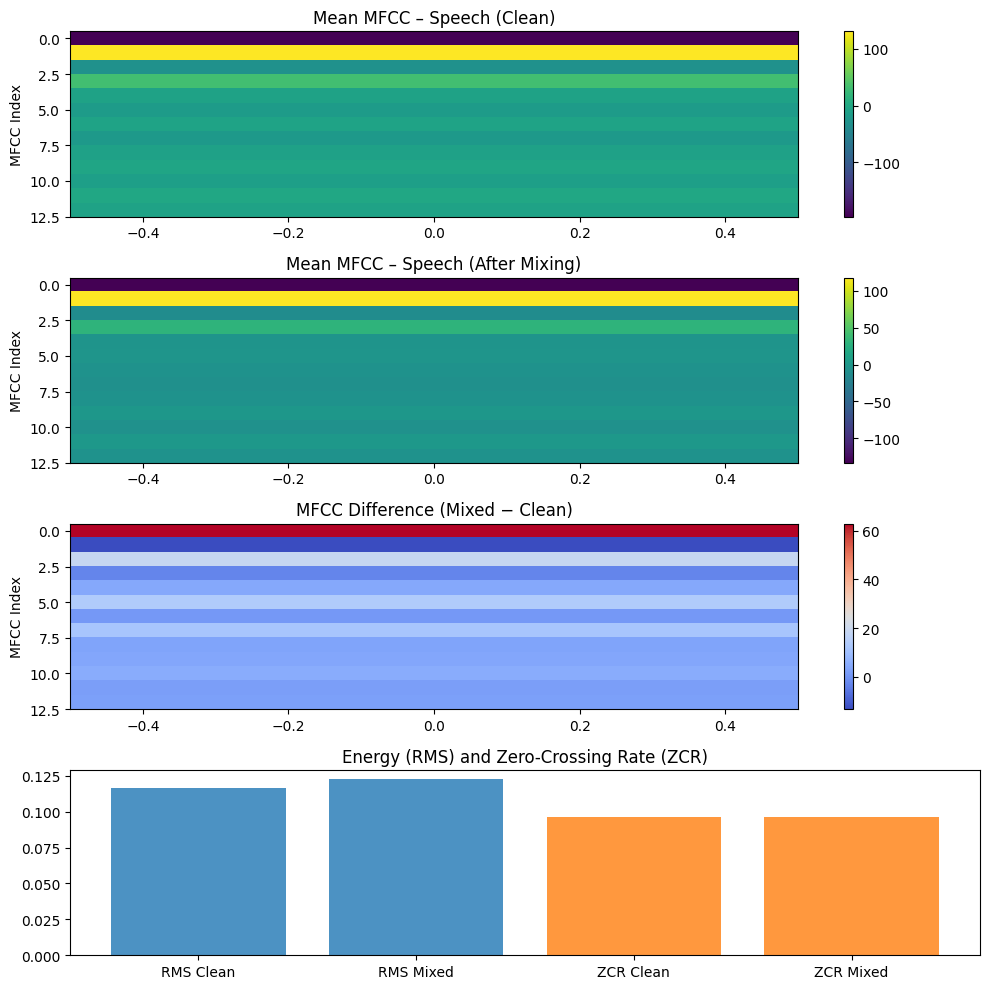

In [3]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

DIR_SPEECH = r"G:/SP2026/AIL303m/split_data/SPEECH"
DIR_MIXED  = r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU"

n_mfcc = 13

# ===============================
# FEATURE EXTRACTION
# ===============================
def extract_features(directory):
    mfcc_all = []
    rms_all  = []
    zcr_all  = []

    for file in os.listdir(directory):
        if not file.endswith(".wav"):
            continue

        y, sr = librosa.load(os.path.join(directory, file), sr=None)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        rms  = librosa.feature.rms(y=y)
        zcr  = librosa.feature.zero_crossing_rate(y)

        mfcc_all.append(np.mean(mfcc, axis=1))
        rms_all.append(np.mean(rms))
        zcr_all.append(np.mean(zcr))

    return (
        np.array(mfcc_all),   # (N, n_mfcc)
        np.array(rms_all),    # (N,)
        np.array(zcr_all)     # (N,)
    )

# ===============================
# COMPUTE FEATURES
# ===============================
mfcc_clean, rms_clean, zcr_clean = extract_features(DIR_SPEECH)
mfcc_mixed, rms_mixed, zcr_mixed = extract_features(DIR_MIXED)

mfcc_clean_mean = np.mean(mfcc_clean, axis=0)
mfcc_mixed_mean = np.mean(mfcc_mixed, axis=0)
mfcc_diff = mfcc_mixed_mean - mfcc_clean_mean

# ===============================
# VISUALIZATION
# ===============================
plt.figure(figsize=(10, 10))

# --- MFCC Clean ---
plt.subplot(4, 1, 1)
plt.imshow(mfcc_clean_mean[:, np.newaxis], aspect="auto", cmap="viridis")
plt.title("Mean MFCC – Speech (Clean)")
plt.ylabel("MFCC Index")
plt.colorbar()

# --- MFCC Mixed ---
plt.subplot(4, 1, 2)
plt.imshow(mfcc_mixed_mean[:, np.newaxis], aspect="auto", cmap="viridis")
plt.title("Mean MFCC – Speech (After Mixing)")
plt.ylabel("MFCC Index")
plt.colorbar()

# --- MFCC Difference ---
plt.subplot(4, 1, 3)
plt.imshow(mfcc_diff[:, np.newaxis], aspect="auto", cmap="coolwarm")
plt.title("MFCC Difference (Mixed − Clean)")
plt.ylabel("MFCC Index")
plt.colorbar()

# --- RMS & ZCR ---
plt.subplot(4, 1, 4)
plt.bar(["RMS Clean", "RMS Mixed"], 
        [np.mean(rms_clean), np.mean(rms_mixed)],
        alpha=0.8)

plt.bar(["ZCR Clean", "ZCR Mixed"], 
        [np.mean(zcr_clean), np.mean(zcr_mixed)],
        alpha=0.8)

plt.title("Energy (RMS) and Zero-Crossing Rate (ZCR)")
plt.tight_layout()
plt.show()


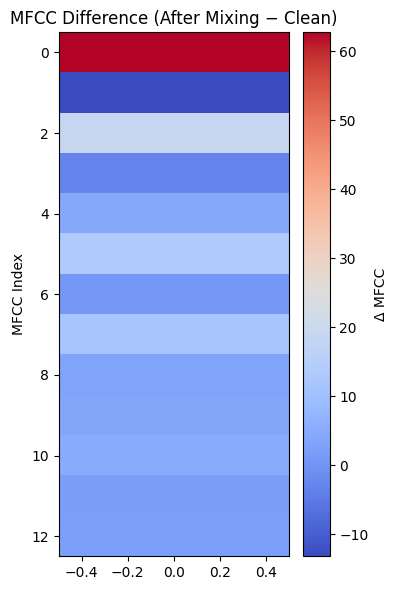

In [4]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

DIR_SPEECH = r"G:/SP2026/AIL303m/split_data/SPEECH"
DIR_MIXED  = r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU"

n_mfcc = 13

def mean_mfcc(directory):
    all_mfcc = []

    for f in os.listdir(directory):
        if not f.endswith(".wav"):
            continue
        y, sr = librosa.load(os.path.join(directory, f), sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        all_mfcc.append(np.mean(mfcc, axis=1))

    return np.mean(all_mfcc, axis=0)

mfcc_clean = mean_mfcc(DIR_SPEECH)
mfcc_mixed = mean_mfcc(DIR_MIXED)

diff = mfcc_mixed - mfcc_clean

plt.figure(figsize=(4, 6))
plt.imshow(diff[:, np.newaxis], aspect="auto", cmap="coolwarm")
plt.title("MFCC Difference (After Mixing − Clean)")
plt.ylabel("MFCC Index")
plt.colorbar(label="Δ MFCC")
plt.tight_layout()
plt.show()


Duration: 30.11 seconds
RMS clean : 0.1845
RMS mixed : 0.1519


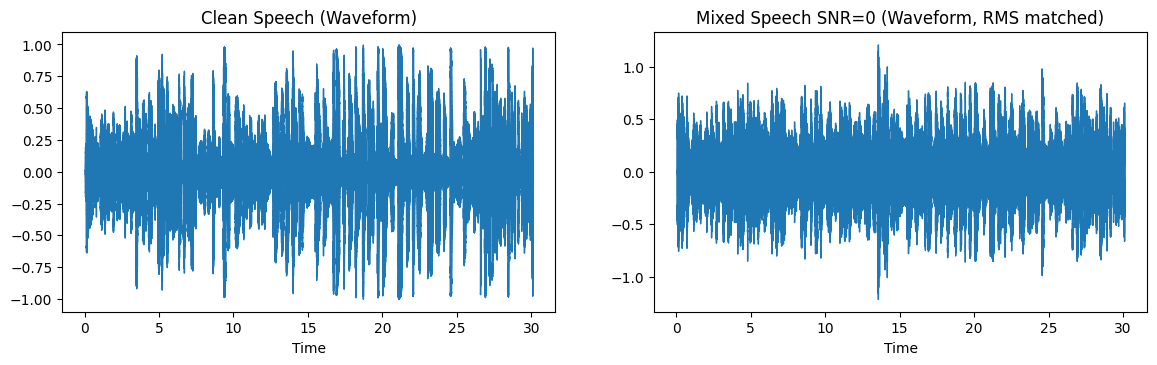

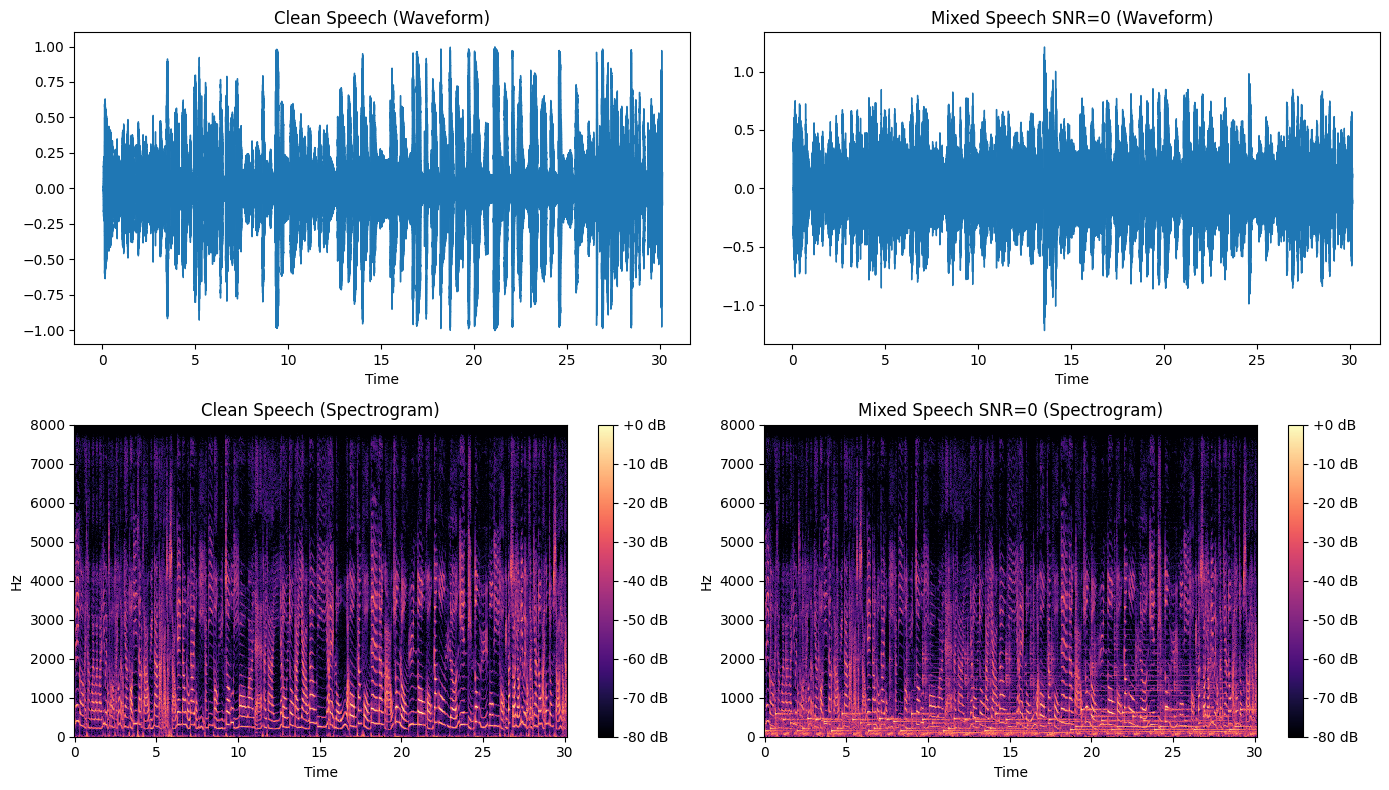

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# PATH
# ==============================
clean_path = r"G:/SP2026/AIL303m/split_data/SPEECH/10.wav"
mixed_path = r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU/2_snr0.wav"

# ==============================
# LOAD AUDIO (GIỮ BIÊN ĐỘ GỐC)
# ==============================
y_clean, sr = librosa.load(clean_path, sr=None, mono=True)
y_mixed, _ = librosa.load(mixed_path, sr=None, mono=True)

# ==============================
# ÉP CÙNG THỜI LƯỢNG
# ==============================
min_len = min(len(y_clean), len(y_mixed))
y_clean = y_clean[:min_len]
y_mixed = y_mixed[:min_len]

print(f"Duration: {min_len/sr:.2f} seconds")

# ==============================
# CĂN BIÊN ĐỘ THEO RMS (KHÔNG LÀM MÉO)
# ==============================
def rms(x):
    return np.sqrt(np.mean(x**2))

rms_clean = rms(y_clean)
rms_mixed = rms(y_mixed)

# scale mixed để RMS = clean
y_mixed_matched = y_mixed * (rms_clean / (rms_mixed + 1e-9))

print(f"RMS clean : {rms_clean:.4f}")
print(f"RMS mixed : {rms_mixed:.4f}")

# ==============================
# SPECTROGRAM
# ==============================
S_clean = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_clean)),
    ref=np.max
)

S_mixed = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_mixed_matched)),
    ref=np.max
)

# ==============================
# VISUALIZATION
# ==============================
plt.figure(figsize=(14, 8))

# Waveform clean
plt.subplot(2, 2, 1)
librosa.display.waveshow(y_clean, sr=sr)
plt.title("Clean Speech (Waveform)")

# Waveform mixed
plt.subplot(2, 2, 2)
librosa.display.waveshow(y_mixed_matched, sr=sr)
plt.title("Mixed Speech SNR=0 (Waveform, RMS matched)")

# ==============================
# SPECTROGRAM (CÙNG THANG dB)
# ==============================
S_clean = np.abs(librosa.stft(y_clean))
S_mixed = np.abs(librosa.stft(y_mixed_matched))

# DÙNG CHUNG MỘT MỐC THAM CHIẾU
ref_val = max(S_clean.max(), S_mixed.max())

S_clean_db = librosa.amplitude_to_db(S_clean, ref=ref_val)
S_mixed_db = librosa.amplitude_to_db(S_mixed, ref=ref_val)

# ==============================
# VISUALIZATION
# ==============================
plt.figure(figsize=(14, 8))

# Waveform clean
plt.subplot(2, 2, 1)
librosa.display.waveshow(y_clean, sr=sr)
plt.title("Clean Speech (Waveform)")

# Waveform mixed
plt.subplot(2, 2, 2)
librosa.display.waveshow(y_mixed_matched, sr=sr)
plt.title("Mixed Speech SNR=0 (Waveform)")

# Spectrogram clean
plt.subplot(2, 2, 3)
librosa.display.specshow(
    S_clean_db,
    sr=sr,
    x_axis="time",
    y_axis="hz",
    vmin=-80, vmax=0   # CỐ ĐỊNH THANG MÀU
)
plt.title("Clean Speech (Spectrogram)")
plt.colorbar(format="%+2.0f dB")

# Spectrogram mixed
plt.subplot(2, 2, 4)
librosa.display.specshow(
    S_mixed_db,
    sr=sr,
    x_axis="time",
    y_axis="hz",
    vmin=-80, vmax=0
)
plt.title("Mixed Speech SNR=0 (Spectrogram)")
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()




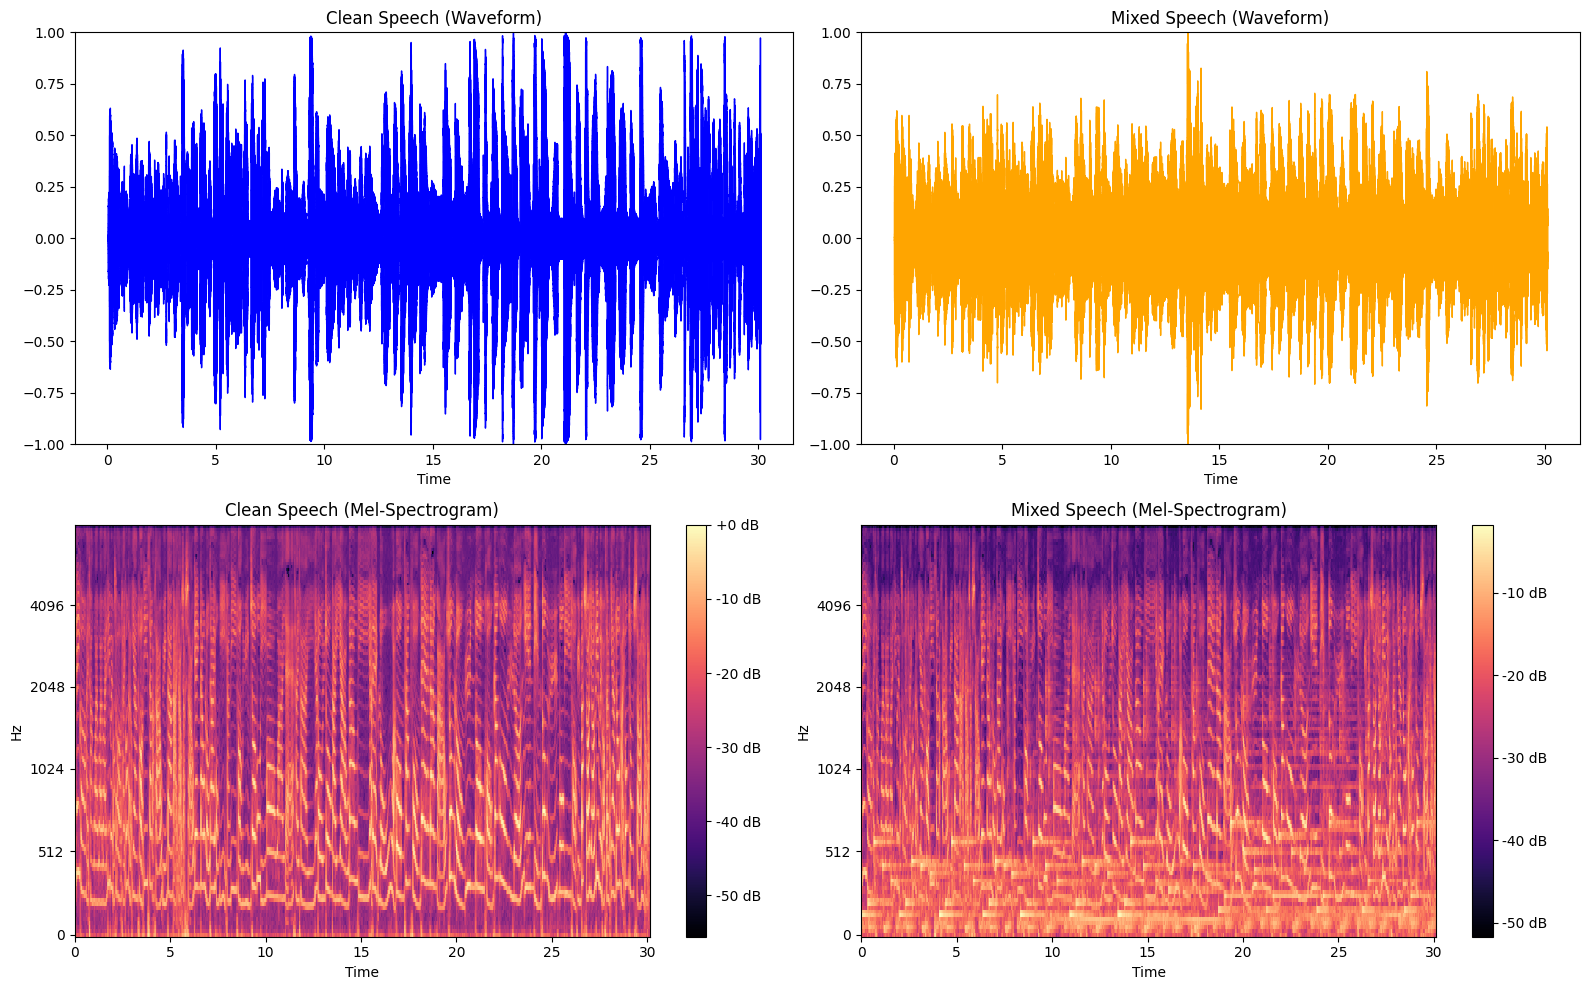

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# PATH (Giữ nguyên)
# ==============================
clean_path = r"G:/SP2026/AIL303m/split_data/SPEECH/10.wav"
mixed_path = r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU/2_snr0.wav"

# ==============================
# LOAD AUDIO (Giữ nguyên)
# ==============================
y_clean, sr = librosa.load(clean_path, sr=None, mono=True)
y_mixed, _  = librosa.load(mixed_path, sr=None, mono=True)

min_len = min(len(y_clean), len(y_mixed))
y_clean = y_clean[:min_len]
y_mixed = y_mixed[:min_len]

# ==============================
# TỐI ƯU SPECTROGRAM ĐỂ PHÂN BIỆT RÕ
# ==============================
# 1. Tăng n_fft để tách bạch các hài âm (Music/Speech Harmonics)
n_fft = 2048
hop_length = 512

S_clean = np.abs(librosa.stft(y_clean, n_fft=n_fft, hop_length=hop_length))
S_mixed = np.abs(librosa.stft(y_mixed, n_fft=n_fft, hop_length=hop_length))

# 2. Sử dụng Mel-Scale (Cực kỳ quan trọng để thấy Music và Speech rõ hơn Hz)
S_clean_mel = librosa.feature.melspectrogram(S=S_clean, sr=sr, n_mels=128)
S_mixed_mel = librosa.feature.melspectrogram(S=S_mixed, sr=sr, n_mels=128)

# 3. Chuẩn hóa dB dựa trên file Clean để thấy rõ sự "nhiễu" ở file Mixed
ref_val = np.max(S_clean_mel)
S_clean_db = librosa.power_to_db(S_clean_mel, ref=ref_val)
S_mixed_db = librosa.power_to_db(S_mixed_mel, ref=ref_val)

# ==============================
# VISUALIZATION
# ==============================
plt.figure(figsize=(16, 10))

# --- Waveforms ---
plt.subplot(2, 2, 1)
librosa.display.waveshow(y_clean, sr=sr, color="blue")
plt.title("Clean Speech (Waveform)")
plt.ylim(-1, 1)

plt.subplot(2, 2, 2)
librosa.display.waveshow(y_mixed, sr=sr, color="orange")
plt.title("Mixed Speech (Waveform)")
plt.ylim(-1, 1)

# --- Spectrograms (Dùng bảng màu 'magma' để tăng độ tương phản) ---
plt.subplot(2, 2, 3)
img1 = librosa.display.specshow(S_clean_db, sr=sr, x_axis="time", y_axis="mel", 
                                 fmax=8000, cmap='magma')
plt.title("Clean Speech (Mel-Spectrogram)")
plt.colorbar(img1, format="%+2.0f dB")

plt.subplot(2, 2, 4)
img2 = librosa.display.specshow(S_mixed_db, sr=sr, x_axis="time", y_axis="mel", 
                                 fmax=8000, cmap='magma')
plt.title("Mixed Speech (Mel-Spectrogram)")
plt.colorbar(img2, format="%+2.0f dB")

plt.tight_layout()
plt.show()

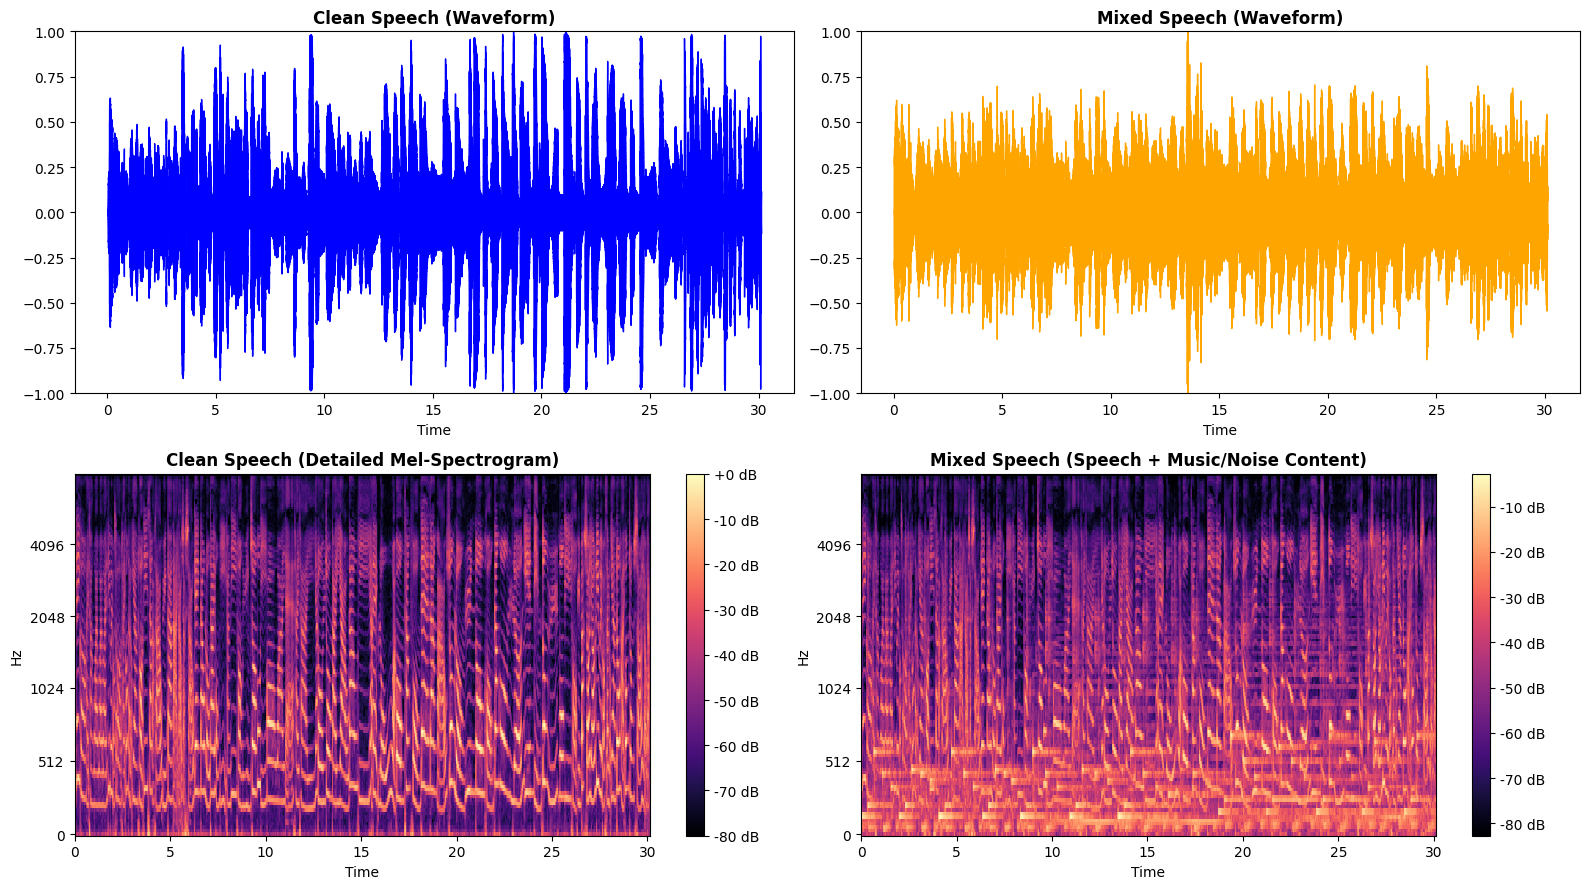

In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# PATH (GIỮ NGUYÊN)
# ==============================
clean_path = r"G:/SP2026/AIL303m/split_data/SPEECH/10.wav"
mixed_path = r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU/2_snr0.wav"

# ==============================
# LOAD AUDIO
# ==============================
y_clean, sr = librosa.load(clean_path, sr=None, mono=True)
y_mixed, _  = librosa.load(mixed_path, sr=None, mono=True)

min_len = min(len(y_clean), len(y_mixed))
y_clean = y_clean[:min_len]
y_mixed = y_mixed[:min_len]

# ==============================
# CHUYỂN SANG MEL-SPECTROGRAM ĐỂ NHÌN RÕ HƠN
# ==============================
# Tăng n_mels và n_fft để nhìn rõ các dải hài âm của Music và Speech
S_clean = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128, n_fft=2048)
S_mixed = librosa.feature.melspectrogram(y=y_mixed, sr=sr, n_mels=128, n_fft=2048)

# Dùng chung một mức tham chiếu để so sánh chính xác độ lớn
ref_val = np.max(S_clean) 

S_clean_db = librosa.power_to_db(S_clean, ref=ref_val)
S_mixed_db = librosa.power_to_db(S_mixed, ref=ref_val)

# ==============================
# VISUALIZATION (NÂNG CẤP ĐỘ TƯƠNG PHẢN)
# ==============================
plt.figure(figsize=(16, 9))

# Waveform Clean
plt.subplot(2, 2, 1)
librosa.display.waveshow(y_clean, sr=sr, color='blue')
plt.title("Clean Speech (Waveform)", fontsize=12, fontweight='bold')
plt.ylim(-1, 1)

# Waveform Mixed (Dễ dàng thấy biên độ nhiễu lấp đầy khoảng lặng)
plt.subplot(2, 2, 2)
librosa.display.waveshow(y_mixed, sr=sr, color='orange')
plt.title("Mixed Speech (Waveform)", fontsize=12, fontweight='bold')
plt.ylim(-1, 1)

# Mel-Spectrogram Clean (Nhìn rõ các vạch đứng của tiếng nói)
plt.subplot(2, 2, 3)
img1 = librosa.display.specshow(S_clean_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000, cmap='magma')
plt.title("Clean Speech (Detailed Mel-Spectrogram)", fontsize=12, fontweight='bold')
plt.colorbar(img1, format="%+2.0f dB")

# Mel-Spectrogram Mixed (Sẽ thấy rõ các đường kẻ ngang của MUSIC đè lên)
plt.subplot(2, 2, 4)
img2 = librosa.display.specshow(S_mixed_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000, cmap='magma')
plt.title("Mixed Speech (Speech + Music/Noise Content)", fontsize=12, fontweight='bold')
plt.colorbar(img2, format="%+2.0f dB")

plt.tight_layout()
plt.show()

Duration compared: 13.18 seconds


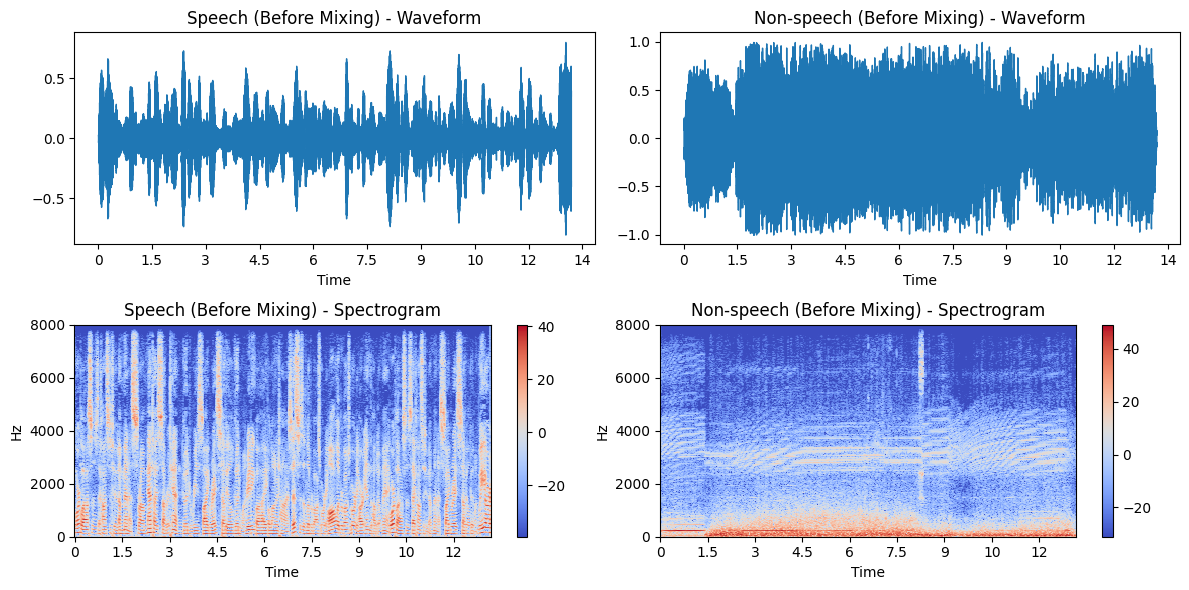

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# PATHS
# ==============================
speech_path = r"G:/SP2026/AIL303m/split_data/SPEECH/1.wav"
music_path  = r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU"

# ==============================
# LOAD AUDIO
# ==============================
y_speech, sr = librosa.load(speech_path, sr=None)
y_music,  _  = librosa.load(music_path, sr=None)

# ==============================
# ÉP CÙNG THỜI LƯỢNG
# ==============================
min_len = min(len(y_speech), len(y_music))
y_speech = y_speech[:min_len]
y_music  = y_music[:min_len]

# ==============================
# MIX CÓ CHỦ ĐÍCH (STRONGER)
# ==============================
alpha = 1.5   # tăng lên 2.0 nếu muốn khác mạnh hơn
y_mixed = y_speech + alpha * y_music

# normalize để tránh clipping
y_mixed = y_mixed / np.max(np.abs(y_mixed))

print(f"Duration (seconds): {min_len / sr:.2f}")

# ==============================
# VISUALIZATION
# ==============================
plt.figure(figsize=(12, 6))

# Waveform
plt.subplot(2, 2, 1)
librosa.display.waveshow(y_speech, sr=sr)
plt.title("Clean Speech (Waveform)")

plt.subplot(2, 2, 2)
librosa.display.waveshow(y_mixed, sr=sr)
plt.title("Speech + Music (Stronger Mix)")

# Spectrogram
S_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_speech)))
S_mixed = librosa.amplitude_to_db(np.abs(librosa.stft(y_mixed)))

plt.subplot(2, 2, 3)
librosa.display.specshow(S_clean, sr=sr, x_axis="time", y_axis="hz")
plt.title("Clean Speech (Spectrogram)")
plt.colorbar()

plt.subplot(2, 2, 4)
librosa.display.specshow(S_mixed, sr=sr, x_axis="time", y_axis="hz")
plt.title("Speech + Music (Spectrogram)")
plt.colorbar()

plt.tight_layout()
plt.show()


Speech files: 1278
Non-speech files: 2520
Speech duration: 58.29 hours
Non-speech duration: 46.35 hours


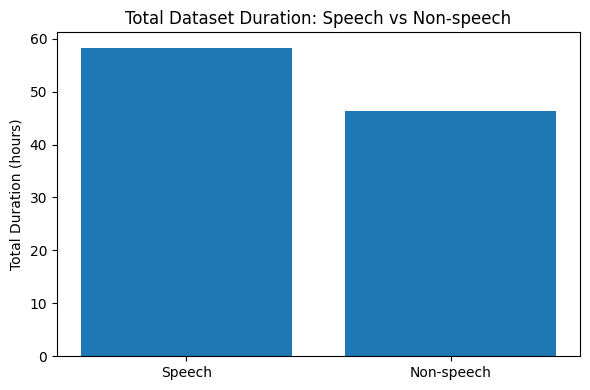

In [12]:
import glob
import librosa
import matplotlib.pyplot as plt
import os

# ==================================================
# 1. KHAI BÁO ĐƯỜNG DẪN 
# ==================================================

speech_dirs = [
    r"G:/SP2026/AIL303m/split_data/SPEECH",
    r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+NO",
    r"G:/SP2026/AIL303m/split_data/MIXING DATA/SP+MU"
]

nonspeech_dirs = [
    r"G:/SP2026/AIL303m/split_data/NOISE",
    r"G:/SP2026/AIL303m/split_data/MUSIC",
    r"G:/SP2026/AIL303m/split_data/MIXING DATA/NO+MU"
]

# ==================================================
# 2. HÀM GOM FILE WAV
# ==================================================
def collect_wav_files(dir_list):
    files = []
    for d in dir_list:
        files.extend(glob.glob(os.path.join(d, "*.wav")))
    return files

speech_files = collect_wav_files(speech_dirs)
nonspeech_files = collect_wav_files(nonspeech_dirs)

# ==================================================
# 3. TÍNH TỔNG THỜI LƯỢNG
# ==================================================
def compute_total_duration(file_list):
    total_seconds = 0.0
    for f in file_list:
        y, sr = librosa.load(f, sr=None)
        total_seconds += len(y) / sr
    return total_seconds

speech_seconds = compute_total_duration(speech_files)
nonspeech_seconds = compute_total_duration(nonspeech_files)

speech_hours = speech_seconds / 3600
nonspeech_hours = nonspeech_seconds / 3600

print(f"Speech files: {len(speech_files)}")
print(f"Non-speech files: {len(nonspeech_files)}")
print(f"Speech duration: {speech_hours:.2f} hours")
print(f"Non-speech duration: {nonspeech_hours:.2f} hours")

# ==================================================
# 4. BIỂU ĐỒ SO SÁNH
# ==================================================
plt.figure(figsize=(6, 4))
plt.bar(
    ["Speech", "Non-speech"],
    [speech_hours, nonspeech_hours]
)

plt.ylabel("Total Duration (hours)")
plt.title("Total Dataset Duration: Speech vs Non-speech")
plt.tight_layout()
plt.show()
